# Terrain Baselines with Tuned Hyperparameters (Strict LORO-CV)

This notebook reproduces the strict LORO-CV evaluation protocol from 07_baslines.ipynb, but uses tuned hyperparameters loaded from results/tuning_best_params.json.

Key rules preserved:
- No run leakage (leave-one-run-out only)
- LabelEncoder fit on train labels inside each fold only
- StandardScaler fit inside each fold via Pipeline
- KNOWN_DEGENERATE enforced strictly (expected to be empty)
- Macro F1 computed over evaluable classes only

In [1]:
from __future__ import annotations

import json
import warnings
from datetime import datetime, timezone
from pathlib import Path
import sys

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, precision_recall_fscore_support
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.utils.class_weight import compute_sample_weight

try:
    from xgboost import XGBClassifier
except ImportError as exc:
    raise ImportError(
        "xgboost is required for this notebook. Install it in the active kernel before running."
    ) from exc

# Project bootstrap (same pattern as prior notebooks)
cwd = Path.cwd()
PROJECT_ROOT = cwd if (cwd / "src").exists() else cwd.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

RANDOM_STATE = 42
N_TOP_MI = 25
RUN_IMBALANCE_COMPARISON = True
SAVE_TUNED_MODELS = False
RUN_RETRAIN_BEST = True

REPORTS_DIR = PROJECT_ROOT / "reports" / "models"
MODELS_DIR = PROJECT_ROOT / "models"
RESULTS_DIR = PROJECT_ROOT / "results"

LABEL_COL = "label"
RUN_COL = "run_id"
ID_COLS = [
    "window_id",
    "run_id",
    "segment_id",
    "label",
    "t_start",
    "t_end",
    "n_samples",
]
LABEL_ORDER = [
    "cobbelstone",
    "dry_dirt_track",
    "grass",
    "muddy_dirt_track",
    "smooth_terrain",
]

KNOWN_DEGENERATE = {}
KNOWN_CONFOUNDED = {
    "log_20260309_141435.414_partB": {
        "cobbelstone": "train=run4 only, test=partB (same original session, consistent speed)",
    },
    "log_20260326_120021.508": {
        "cobbelstone": "train=partB only, test=run4 (different session)",
    },
}

CLASS_SAMPLE_WARN_THRESHOLD = 30

for out_dir in [REPORTS_DIR, MODELS_DIR, RESULTS_DIR]:
    out_dir.mkdir(parents=True, exist_ok=True)

print("Configuration loaded")
print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"RUN_IMBALANCE_COMPARISON: {RUN_IMBALANCE_COMPARISON}")
print(f"SAVE_TUNED_MODELS: {SAVE_TUNED_MODELS}")
print(f"RUN_RETRAIN_BEST: {RUN_RETRAIN_BEST}")
from src.evaluation import (
    compute_fold_metrics,
    fmt_mean_std,
    make_base_models,
    row_normalize,
    summarize_group,
)


Configuration loaded
PROJECT_ROOT: /Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis
RUN_IMBALANCE_COMPARISON: True
SAVE_TUNED_MODELS: False
RUN_RETRAIN_BEST: True


## Load Data and Tuned Parameters

This cell loads:
- data/processed/dataset_A_pruned_5run.csv
- data/processed/top_mi_features.json (top 25 MI features)
- results/tuning_best_params.json (best params from 07 baseline tuning)

It also validates strict schema, labels, and fold degeneracy assumptions.

In [2]:
DATASET_PATH = PROJECT_ROOT / "data" / "processed" / "dataset_A_pruned_5run.csv"
TOP_MI_PATH = PROJECT_ROOT / "data" / "processed" / "top_mi_features.json"
TUNING_PARAMS_PATH = PROJECT_ROOT / "results" / "tuning_best_params.json"
BASELINE_SUMMARY_PATH = PROJECT_ROOT / "results" / "baseline_metrics_summary.csv"

if not DATASET_PATH.exists():
    raise FileNotFoundError(f"Missing dataset: {DATASET_PATH}")
if not TOP_MI_PATH.exists():
    raise FileNotFoundError(f"Missing MI feature list: {TOP_MI_PATH}")
if not TUNING_PARAMS_PATH.exists():
    raise FileNotFoundError(f"Missing tuned params file: {TUNING_PARAMS_PATH}")

df = pd.read_csv(DATASET_PATH)

with TOP_MI_PATH.open("r", encoding="utf-8") as f:
    top_mi_raw = json.load(f)

with TUNING_PARAMS_PATH.open("r", encoding="utf-8") as f:
    tuned_params_raw = json.load(f)

if isinstance(top_mi_raw, dict):
    if "top_features" in top_mi_raw and isinstance(top_mi_raw["top_features"], list):
        top_mi_features = list(top_mi_raw["top_features"])
    else:
        top_mi_features = list(top_mi_raw.keys())
elif isinstance(top_mi_raw, list):
    top_mi_features = list(top_mi_raw)
else:
    raise ValueError("Unsupported top_mi_features.json structure. Expected list or dict.")

required_models = {"LogisticRegression", "RandomForest", "XGBoost"}
if not isinstance(tuned_params_raw, dict):
    raise ValueError("tuning_best_params.json must be a dict keyed by model name.")
missing_models = sorted(required_models - set(tuned_params_raw.keys()))
if missing_models:
    raise ValueError(f"tuning_best_params.json missing model keys: {missing_models}")

missing_id_cols = [c for c in ID_COLS if c not in df.columns]
if missing_id_cols:
    raise KeyError(f"Missing ID columns in dataset: {missing_id_cols}")

if LABEL_COL not in df.columns or RUN_COL not in df.columns:
    raise KeyError(f"Dataset must contain {LABEL_COL} and {RUN_COL}.")

labels_found = sorted(df[LABEL_COL].astype(str).unique().tolist())
if set(labels_found) != set(LABEL_ORDER):
    raise ValueError(
        "Strict label check failed. Expected labels: "
        f"{sorted(LABEL_ORDER)} | Found: {labels_found}"
    )

run_ids = sorted(df[RUN_COL].astype(str).unique().tolist())
if len(run_ids) < 2:
    raise ValueError("LORO-CV requires at least two unique runs.")

feature_cols_all = [c for c in df.columns if c not in ID_COLS]
feature_cols_mi = [c for c in top_mi_features if c in feature_cols_all]
if N_TOP_MI is not None and N_TOP_MI > 0:
    feature_cols_mi = feature_cols_mi[:N_TOP_MI]
if not feature_cols_mi:
    raise ValueError("No overlap between top_mi_features.json and dataset columns.")

print(f"Dataset shape: {df.shape}")
print(f"Feature count (all pruned): {len(feature_cols_all)}")
print(f"Feature count (top MI): {len(feature_cols_mi)}")
print("\nLoaded tuned params for:")
for m in sorted(required_models):
    print(f"  {m}: {tuned_params_raw[m]}")

fold_preview_rows = []
class_evaluable_fold_counts = {label: 0 for label in LABEL_ORDER}

for test_run in run_ids:
    train_df = df[df[RUN_COL] != test_run]
    test_df = df[df[RUN_COL] == test_run]

    train_labels = set(train_df[LABEL_COL].astype(str))
    test_labels = set(test_df[LABEL_COL].astype(str))

    missing_from_train = sorted(test_labels - train_labels)
    expected_missing = sorted(KNOWN_DEGENERATE.get(test_run, []))

    if missing_from_train != expected_missing:
        raise ValueError(
            f"KNOWN_DEGENERATE mismatch for {test_run}. "
            f"Expected {expected_missing}, observed {missing_from_train}."
        )

    for label in LABEL_ORDER:
        if label in train_labels and label in test_labels:
            class_evaluable_fold_counts[label] += 1

    fold_preview_rows.append(
        {
            "test_run": test_run,
            "train_windows": int(len(train_df)),
            "test_windows": int(len(test_df)),
            "missing_from_train": ", ".join(missing_from_train) if missing_from_train else "None",
        }
    )

fold_preview_df = pd.DataFrame(fold_preview_rows)
print("\nLORO fold preview:")
print(fold_preview_df.to_string(index=False))

Dataset shape: (2346, 127)
Feature count (all pruned): 120
Feature count (top MI): 8

Loaded tuned params for:
  LogisticRegression: {'clf__C': 0.1}
  RandomForest: {'clf__n_estimators': 200, 'clf__min_samples_leaf': 2, 'clf__max_depth': 10}
  XGBoost: {'clf__subsample': 1.0, 'clf__n_estimators': 500, 'clf__max_depth': 6, 'clf__learning_rate': 0.2}

LORO fold preview:
                     test_run  train_windows  test_windows missing_from_train
      log_20260223_142511.490           2053           293               None
      log_20260226_102148.990           2201           145               None
log_20260309_141435.414_partA           1682           664               None
log_20260309_141435.414_partB           1682           664               None
      log_20260326_120021.508           1766           580               None


## Build Tuned Model Variants

Construct tuned base pipelines using the loaded best parameters, then generate unweighted and balanced variants.

Balanced handling:
- LogisticRegression and RandomForest: class_weight='balanced'
- XGBoost: fold-wise sample_weight='balanced'

In [3]:
def _strip_clf_prefix(param_map: dict[str, object]) -> dict[str, object]:
    clean = {}
    for k, v in param_map.items():
        clean[k[len("clf__"):] if k.startswith("clf__") else k] = v
    return clean


def make_tuned_base_models(random_state: int, tuned_params: dict[str, dict[str, object]]) -> dict[str, Pipeline]:
    lr_params = _strip_clf_prefix(dict(tuned_params["LogisticRegression"]))
    rf_params = _strip_clf_prefix(dict(tuned_params["RandomForest"]))
    xgb_params = _strip_clf_prefix(dict(tuned_params["XGBoost"]))

    lr_defaults = {
        "C": 1.0,
        "max_iter": 2000,
        "solver": "lbfgs",
        "random_state": random_state,
    }
    rf_defaults = {
        "n_estimators": 300,
        "max_depth": None,
        "n_jobs": -1,
        "random_state": random_state,
    }
    xgb_defaults = {
        "n_estimators": 300,
        "learning_rate": 0.1,
        "max_depth": 6,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
        "eval_metric": "mlogloss",
        "random_state": random_state,
    }

    lr_defaults.update(lr_params)
    rf_defaults.update(rf_params)
    xgb_defaults.update(xgb_params)

    lr_defaults["random_state"] = random_state
    rf_defaults["random_state"] = random_state
    rf_defaults["n_jobs"] = -1
    xgb_defaults["random_state"] = random_state
    xgb_defaults["eval_metric"] = "mlogloss"

    return {
        "LogisticRegression": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(**lr_defaults)),
        ]),
        "RandomForest": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", RandomForestClassifier(**rf_defaults)),
        ]),
        "XGBoost": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", XGBClassifier(**xgb_defaults)),
        ]),
    }


def build_model_variants(run_imbalance_comparison: bool = True) -> list[dict[str, object]]:
    base_models = make_tuned_base_models(RANDOM_STATE, tuned_params_raw)
    variants: list[dict[str, object]] = []

    for model_name, pipeline in base_models.items():
        variants.append(
            {
                "variant_name": f"{model_name}_unweighted",
                "base_model": model_name,
                "imbalance": "unweighted",
                "pipeline": clone(pipeline),
                "requires_encoded_labels": model_name == "XGBoost",
                "needs_sample_weight": False,
            }
        )

        if run_imbalance_comparison:
            balanced_pipe = clone(pipeline)
            needs_sample_weight = False

            if model_name in {"LogisticRegression", "RandomForest"}:
                balanced_pipe.set_params(clf__class_weight="balanced")
            elif model_name == "XGBoost":
                needs_sample_weight = True

            variants.append(
                {
                    "variant_name": f"{model_name}_balanced",
                    "base_model": model_name,
                    "imbalance": "balanced",
                    "pipeline": balanced_pipe,
                    "requires_encoded_labels": model_name == "XGBoost",
                    "needs_sample_weight": needs_sample_weight,
                }
            )

    return variants


model_variants = build_model_variants(run_imbalance_comparison=RUN_IMBALANCE_COMPARISON)

print("Model variants:")
for variant in model_variants:
    print(
        f" - {variant['variant_name']} | encoded_labels={variant['requires_encoded_labels']} "
        f"| sample_weight={variant['needs_sample_weight']}"
    )

Model variants:
 - LogisticRegression_unweighted | encoded_labels=False | sample_weight=False
 - LogisticRegression_balanced | encoded_labels=False | sample_weight=False
 - RandomForest_unweighted | encoded_labels=False | sample_weight=False
 - RandomForest_balanced | encoded_labels=False | sample_weight=False
 - XGBoost_unweighted | encoded_labels=True | sample_weight=False
 - XGBoost_balanced | encoded_labels=True | sample_weight=True


## LORO-CV Evaluation Loop (Tuned)

Identical fold protocol as baseline:
- Evaluate both feature sets: all and top_mi
- Compute fold metrics with evaluable_classes
- Capture per-class rows, confusion records, and interpretability artifacts

## Tuned Results Tables

Create per-fold and aggregate summary tables, then save:
- results/tuned_metrics_per_fold.csv
- results/tuned_metrics_summary.csv

## Baseline vs Tuned Comparison

Load baseline summary from 07 and show metric deltas:
- delta_macro_f1 = tuned_macro_f1_mean - baseline_macro_f1_mean
- delta_accuracy = tuned_accuracy_mean - baseline_accuracy_mean

In [6]:
baseline_df = None
comparison_df = None

if BASELINE_SUMMARY_PATH.exists():
    baseline_df = pd.read_csv(BASELINE_SUMMARY_PATH)

    join_cols = ["model", "feature_set", "imbalance"]
    baseline_keep = baseline_df[join_cols + ["accuracy_mean", "macro_f1_mean"]].rename(
        columns={
            "accuracy_mean": "baseline_accuracy_mean",
            "macro_f1_mean": "baseline_macro_f1_mean",
        }
    )

    tuned_keep = summary_df[join_cols + ["accuracy_mean", "macro_f1_mean"]].rename(
        columns={
            "accuracy_mean": "tuned_accuracy_mean",
            "macro_f1_mean": "tuned_macro_f1_mean",
        }
    )

    comparison_df = tuned_keep.merge(baseline_keep, on=join_cols, how="left")
    comparison_df["delta_accuracy"] = comparison_df["tuned_accuracy_mean"] - comparison_df["baseline_accuracy_mean"]
    comparison_df["delta_macro_f1"] = comparison_df["tuned_macro_f1_mean"] - comparison_df["baseline_macro_f1_mean"]

    print("Baseline vs Tuned delta table (tuned - baseline):")
    print(
        comparison_df.sort_values(join_cols)[
            join_cols
            + [
                "baseline_macro_f1_mean",
                "tuned_macro_f1_mean",
                "delta_macro_f1",
                "baseline_accuracy_mean",
                "tuned_accuracy_mean",
                "delta_accuracy",
            ]
        ].to_string(index=False)
    )
else:
    print(f"Baseline summary not found: {BASELINE_SUMMARY_PATH}")
    print("Skipping side-by-side delta table.")

Baseline vs Tuned delta table (tuned - baseline):
             model feature_set  imbalance  baseline_macro_f1_mean  tuned_macro_f1_mean  delta_macro_f1  baseline_accuracy_mean  tuned_accuracy_mean  delta_accuracy
LogisticRegression         all   balanced                0.753137             0.759200        0.006063                0.735466             0.734686       -0.000780
LogisticRegression         all unweighted                0.749015             0.746138       -0.002878                0.732011             0.724747       -0.007264
LogisticRegression      top_mi   balanced                0.763033             0.732249       -0.030784                0.729233             0.684383       -0.044850
LogisticRegression      top_mi unweighted                0.757954             0.668885       -0.089068                0.726724             0.640736       -0.085988
      RandomForest         all   balanced                0.745440             0.748209        0.002768                0.724110    

## Confusion Matrices (Tuned)

For each model (best imbalance variant on all features), generate:
- Aggregated confusion matrix across non-degenerate folds only
- Per-fold confusion matrix grid

Saved to reports/models/tuned_confusion_matrix_*.png

## Per-Class Metrics (Tuned)

Compute precision/recall/F1 summaries by class for each model using the selected best imbalance on all features.

Saved to results/tuned_per_class_metrics_*.csv

## Feature Importance and Coefficients (Tuned)

- RandomForest/XGBoost: mean feature_importances_ across folds
- LogisticRegression: mean coefficient heatmap across folds

This cell also checks optional baseline ranking files for rank-shift notes.

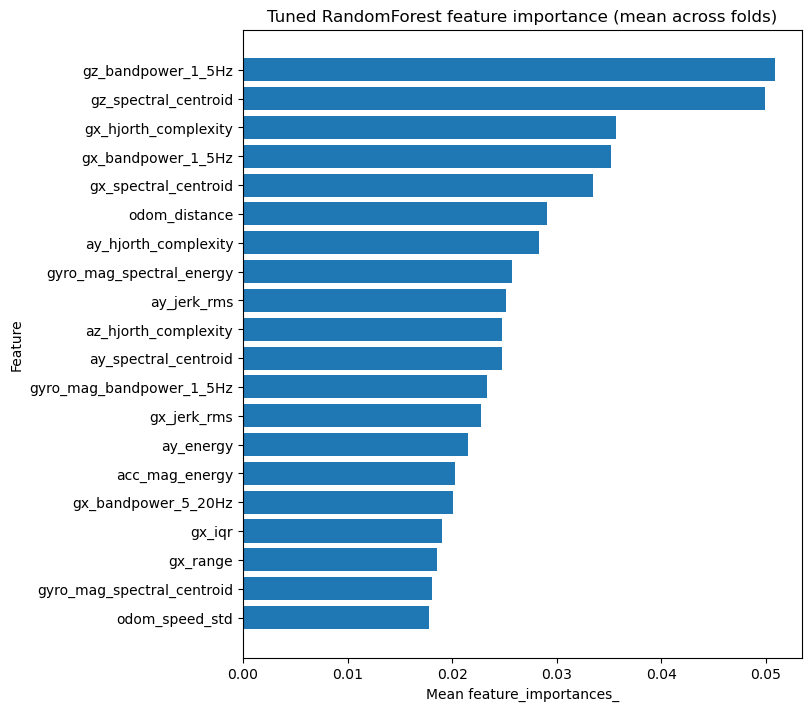

Top 10 for tuned RandomForest:
['gz_bandpower_1_5Hz', 'gz_spectral_centroid', 'gx_hjorth_complexity', 'gx_bandpower_1_5Hz', 'gx_spectral_centroid', 'odom_distance', 'ay_hjorth_complexity', 'gyro_mag_spectral_energy', 'ay_jerk_rms', 'az_hjorth_complexity']
Saved: /Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/reports/models/tuned_feature_importance_randomforest.png


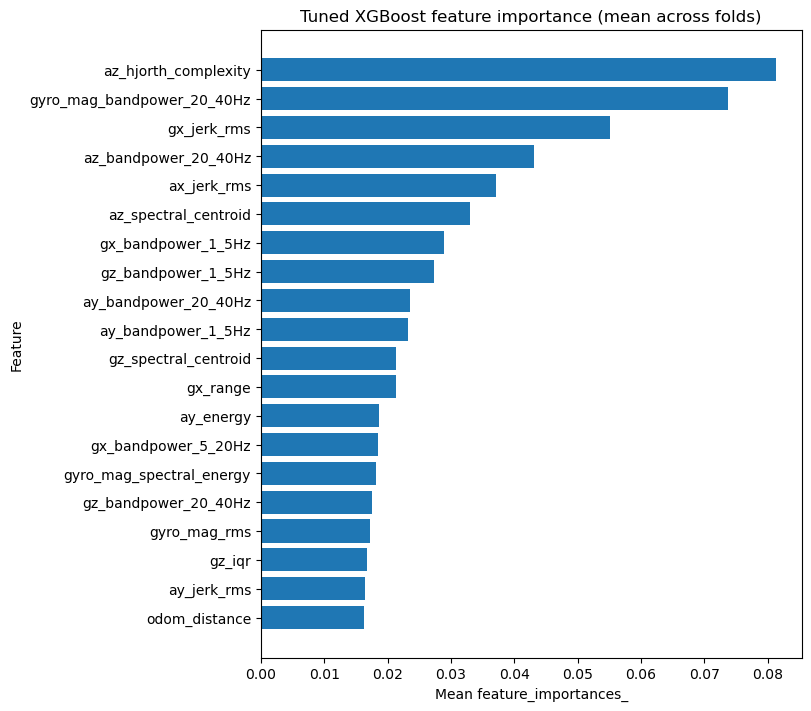

Top 10 for tuned XGBoost:
['az_hjorth_complexity', 'gyro_mag_bandpower_20_40Hz', 'gx_jerk_rms', 'az_bandpower_20_40Hz', 'ax_jerk_rms', 'az_spectral_centroid', 'gx_bandpower_1_5Hz', 'gz_bandpower_1_5Hz', 'ay_bandpower_20_40Hz', 'ay_bandpower_1_5Hz']
Saved: /Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/reports/models/tuned_feature_importance_xgboost.png


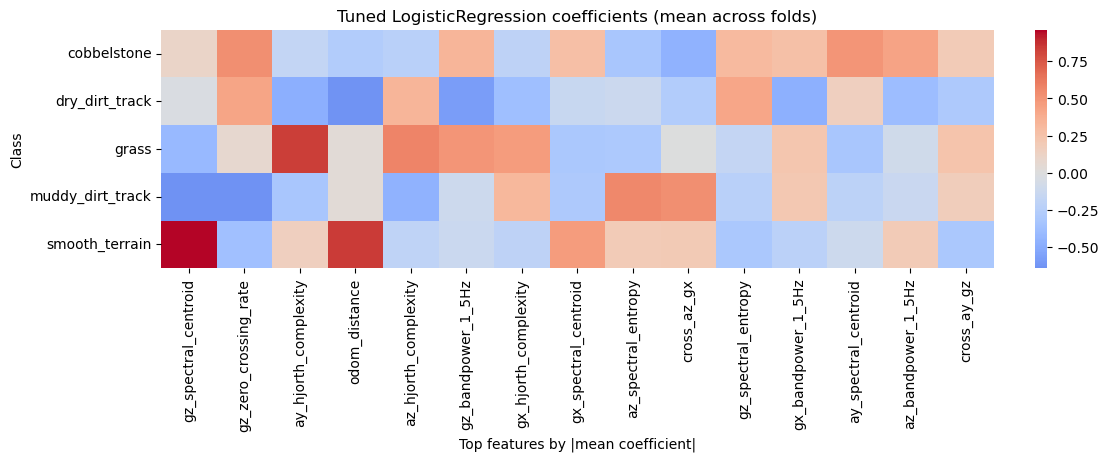

Saved: /Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/reports/models/tuned_lr_coefficients.png

Top-10 overlap between tuned RandomForest and tuned XGBoost:
['az_hjorth_complexity', 'gx_bandpower_1_5Hz', 'gz_bandpower_1_5Hz']

Baseline feature ranking file not found; cannot quantify rank shifts directly.


In [9]:
top10_by_model: dict[str, list[str]] = {}

for model_name in ["RandomForest", "XGBoost"]:
    imbalance = best_imbalance_by_model.get(model_name)
    if imbalance is None:
        continue

    key = (model_name, "all", imbalance)
    fold_importances = feature_importance_store.get(key, [])
    if not fold_importances:
        warnings.warn(f"No stored importances for {key}.")
        continue

    imp_df = pd.concat(fold_importances, axis=1).T
    imp_mean = imp_df.mean(axis=0).sort_values(ascending=False)

    top20 = imp_mean.head(20).sort_values(ascending=True)
    fig, ax = plt.subplots(figsize=(8, 7), constrained_layout=True)
    ax.barh(top20.index, top20.values)
    ax.set_title(f"Tuned {model_name} feature importance (mean across folds)")
    ax.set_xlabel("Mean feature_importances_")
    ax.set_ylabel("Feature")

    out_path = REPORTS_DIR / f"tuned_feature_importance_{model_name.lower()}.png"
    fig.savefig(out_path, dpi=200, bbox_inches="tight")
    plt.show()

    top10 = imp_mean.head(10).index.tolist()
    top10_by_model[model_name] = top10
    print(f"Top 10 for tuned {model_name}:")
    print(top10)
    print(f"Saved: {out_path}")

lr_imbalance = best_imbalance_by_model.get("LogisticRegression")
if lr_imbalance is not None:
    lr_key = ("all", lr_imbalance)
    lr_folds = lr_coef_store.get(lr_key, [])

    if lr_folds:
        aligned = [coef.reindex(index=LABEL_ORDER, columns=feature_cols_all) for coef in lr_folds]
        stack = np.stack([a.to_numpy(dtype=float) for a in aligned], axis=0)
        mean_coef = np.nanmean(stack, axis=0)
        mean_coef_df = pd.DataFrame(mean_coef, index=LABEL_ORDER, columns=feature_cols_all)

        top15 = mean_coef_df.abs().mean(axis=0).sort_values(ascending=False).head(15).index.tolist()
        plot_df = mean_coef_df[top15]

        fig, ax = plt.subplots(figsize=(11, 4.5), constrained_layout=True)
        sns.heatmap(plot_df, cmap="coolwarm", center=0, ax=ax)
        ax.set_title("Tuned LogisticRegression coefficients (mean across folds)")
        ax.set_xlabel("Top features by |mean coefficient|")
        ax.set_ylabel("Class")

        lr_out = REPORTS_DIR / "tuned_lr_coefficients.png"
        fig.savefig(lr_out, dpi=200, bbox_inches="tight")
        plt.show()
        print(f"Saved: {lr_out}")

if "RandomForest" in top10_by_model and "XGBoost" in top10_by_model:
    overlap = sorted(set(top10_by_model["RandomForest"]).intersection(set(top10_by_model["XGBoost"])))
    print("\nTop-10 overlap between tuned RandomForest and tuned XGBoost:")
    print(overlap if overlap else "None")

baseline_rank_candidates = [
    PROJECT_ROOT / "results" / "baseline_top10_features.json",
    PROJECT_ROOT / "results" / "baseline_feature_rankings.json",
]
baseline_rank_path = next((p for p in baseline_rank_candidates if p.exists()), None)
if baseline_rank_path is None:
    print("\nBaseline feature ranking file not found; cannot quantify rank shifts directly.")
else:
    with baseline_rank_path.open("r", encoding="utf-8") as f:
        baseline_rank_data = json.load(f)

    print(f"\nComparing tuned top-10 against baseline ranking file: {baseline_rank_path}")
    for model_name, tuned_top10 in top10_by_model.items():
        baseline_top10 = baseline_rank_data.get(model_name, [])
        if not baseline_top10:
            print(f"  {model_name}: no baseline ranking found in file.")
            continue
        entered = [f for f in tuned_top10 if f not in baseline_top10]
        dropped = [f for f in baseline_top10 if f not in tuned_top10]
        print(f"  {model_name}: entered={entered if entered else 'None'} | dropped={dropped if dropped else 'None'}")

## Final Retrain + Tuned Summary

Retrain the best tuned model on all data, save:
- models/final_tuned_<modelname>.pkl
- models/final_tuned_model_metadata.json

LORO-CV remains the only valid performance estimate.

In [10]:
best_model_name = None
best_feature_set = None
best_macro_f1 = np.nan
best_imbalance = None

if RUN_RETRAIN_BEST:
    candidates = summary_df[(summary_df["feature_set"] == "all") & (summary_df["imbalance"] == "balanced")].copy()
    if candidates.empty:
        candidates = summary_df[summary_df["feature_set"] == "all"].copy()

    if candidates.empty:
        raise RuntimeError("No candidates available for final tuned retraining.")

    best_row = candidates.sort_values("macro_f1_mean", ascending=False).iloc[0]
    best_model_name = str(best_row["model"])
    best_feature_set = str(best_row["feature_set"])
    best_imbalance = str(best_row["imbalance"])
    best_macro_f1 = float(best_row["macro_f1_mean"])

    selected_variant = next(
        v
        for v in model_variants
        if v["base_model"] == best_model_name and v["imbalance"] == best_imbalance
    )

    final_pipeline = clone(selected_variant["pipeline"])
    final_feature_cols = feature_cols_all if best_feature_set == "all" else feature_cols_mi
    X_full = df[final_feature_cols].copy()
    y_full = df[LABEL_COL].astype(str).to_numpy()

    final_label_encoder = None
    fit_kwargs = {}

    if bool(selected_variant["requires_encoded_labels"]):
        final_label_encoder = LabelEncoder()
        y_full_enc = final_label_encoder.fit_transform(y_full)
        if bool(selected_variant["needs_sample_weight"]):
            fit_kwargs["clf__sample_weight"] = compute_sample_weight("balanced", y_full_enc)
        final_pipeline.fit(X_full, y_full_enc, **fit_kwargs)
    else:
        final_pipeline.fit(X_full, y_full)

    final_bundle = {
        "pipeline": final_pipeline,
        "label_encoder": final_label_encoder,
        "feature_columns": final_feature_cols,
        "label_order": LABEL_ORDER,
        "model": best_model_name,
        "imbalance": best_imbalance,
        "is_tuned": True,
    }

    final_model_path = MODELS_DIR / f"final_tuned_{best_model_name.lower()}.pkl"
    joblib.dump(final_bundle, final_model_path)

    baseline_macro = np.nan
    if comparison_df is not None:
        hit = comparison_df[
            (comparison_df["model"] == best_model_name)
            & (comparison_df["feature_set"] == best_feature_set)
            & (comparison_df["imbalance"] == best_imbalance)
        ]
        if not hit.empty:
            baseline_macro = float(hit.iloc[0]["baseline_macro_f1_mean"])

    metadata = {
        "model_name": best_model_name,
        "feature_set": best_feature_set,
        "imbalance": best_imbalance,
        "feature_columns": final_feature_cols,
        "label_order": LABEL_ORDER,
        "training_date": datetime.now(timezone.utc).isoformat(),
        "macro_f1_loro_cv_tuned": best_macro_f1,
        "macro_f1_loro_cv_baseline": baseline_macro,
        "macro_f1_delta_tuned_minus_baseline": (
            float(best_macro_f1 - baseline_macro)
            if not np.isnan(baseline_macro)
            else np.nan
        ),
    }

    metadata_path = MODELS_DIR / "final_tuned_model_metadata.json"
    with metadata_path.open("w", encoding="utf-8") as f:
        json.dump(metadata, f, indent=2)

    print("This tuned model is trained on all available data including runs used in CV.")
    print("LORO-CV metrics remain the only valid performance estimate.")
    print(f"Saved final tuned model: {final_model_path}")
    print(f"Saved tuned metadata: {metadata_path}")
else:
    print("RUN_RETRAIN_BEST is False. Skipping final tuned retrain.")

print("\n" + "=" * 60)
print("TUNED RESULTS SUMMARY")
print("=" * 60)
print(f"Split strategy : LORO-CV ({len(run_ids)} folds, leave-one-run-out)")
print(f"Feature sets   : All pruned ({len(feature_cols_all)} features) | Top MI ({len(feature_cols_mi)} features)")
print("Imbalance      : balanced vs unweighted comparison")

summary_print = summary_df.copy()
summary_print["macro_f1"] = summary_print.apply(
    lambda r: f"{r['macro_f1_mean']:.3f} +/- {r['macro_f1_std']:.3f}", axis=1
)
summary_print["acc"] = summary_print.apply(
    lambda r: f"{r['accuracy_mean']:.3f} +/- {r['accuracy_std']:.3f}", axis=1
)
summary_print["folds"] = summary_print["evaluable_folds"].astype(int).astype(str) + f"/{len(run_ids)}"

print("Model | Features | Balanced | Macro F1 (mean+/-std) | Acc (mean+/-std) | Folds")
for _, row in summary_print.sort_values(["model", "feature_set", "imbalance"]).iterrows():
    balanced_txt = "yes" if row["imbalance"] == "balanced" else "no"
    print(
        f"{row['model']:20s} | {row['feature_set']:7s} | {balanced_txt:8s} | "
        f"{row['macro_f1']:21s} | {row['acc']:19s} | {row['folds']}"
    )

print("\n* macro F1 computed over evaluable classes per fold.")
for cls, count in class_evaluable_fold_counts.items():
    if count < len(run_ids):
        reason = (
            "2/5 folds only (partA+partB split from original run 3)"
            if cls == "dry_dirt_track"
            else "limited run coverage"
        )
        print(f"  {cls}: {count}/{len(run_ids)} folds evaluable ({reason})")

all_confounded = set()
for v in KNOWN_CONFOUNDED.values():
    all_confounded.update(v.keys())
if all_confounded:
    print(f"\nC Speed-regime confounded classes (evaluable but biased): {sorted(all_confounded)}")
    print("  cobbelstone: run 3 and run 4 folds have different speed regimes.")

if comparison_df is not None:
    print("\nBest tuned row with baseline delta:")
    best_join = comparison_df[
        (comparison_df["model"] == best_model_name)
        & (comparison_df["feature_set"] == best_feature_set)
        & (comparison_df["imbalance"] == best_imbalance)
    ]
    if not best_join.empty:
        bj = best_join.iloc[0]
        print(
            f"{best_model_name} | {best_feature_set} | {best_imbalance} | "
            f"baseline macro F1={bj['baseline_macro_f1_mean']:.3f} | "
            f"tuned macro F1={bj['tuned_macro_f1_mean']:.3f} | "
            f"delta={bj['delta_macro_f1']:.3f}"
        )

if best_model_name is not None:
    print(
        f"\nBest tuned model: {best_model_name} | {best_feature_set} | "
        f"macro F1 = {best_macro_f1:.3f}"
    )

print("\nSaved:")
print(f"  {RESULTS_DIR / 'tuned_metrics_per_fold.csv'}")
print(f"  {RESULTS_DIR / 'tuned_metrics_summary.csv'}")
print(f"  {RESULTS_DIR / 'tuned_per_class_metrics_*.csv'}")
print(f"  {REPORTS_DIR / 'tuned_confusion_matrix_*.png'}")
print(f"  {REPORTS_DIR / 'tuned_feature_importance_*.png'}")
if best_model_name is not None:
    print(f"  {MODELS_DIR / ('final_tuned_' + best_model_name.lower() + '.pkl')}")

print("=" * 60)

This tuned model is trained on all available data including runs used in CV.
LORO-CV metrics remain the only valid performance estimate.
Saved final tuned model: /Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/models/final_tuned_logisticregression.pkl
Saved tuned metadata: /Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/models/final_tuned_model_metadata.json

TUNED RESULTS SUMMARY
Split strategy : LORO-CV (5 folds, leave-one-run-out)
Feature sets   : All pruned (120 features) | Top MI (8 features)
Imbalance      : balanced vs unweighted comparison
Model | Features | Balanced | Macro F1 (mean+/-std) | Acc (mean+/-std) | Folds
LogisticRegression   | all     | yes      | 0.759 +/- 0.111       | 0.735 +/- 0.158     | 5/5
LogisticRegression   | all     | no       | 0.746 +/- 0.108       | 0.725 +/- 0.155     | 5/5
LogisticRegression   | top_mi  | yes      | 0.732 +/- 0.097       | 0.684 +/- 0.146     | 5/5
LogisticRegression 